# 03 — Evaluation, Cost, Explanation and Fairness

Produces the results for Chapter 4. Loads the artifacts saved by notebook 02,
so nothing is retrained here.

| Section | Chapter 3 reference | Chapter 4 output |
|---|---|---|
| 1-2 | 3.11.2 | Discrimination: ROC-AUC, PR-AUC, KS |
| 3 | 3.11.4 | Calibration: Brier, reliability diagrams |
| 4 | 3.8.3, 3.10 | Threshold comparison: 0.5, p*, empirical |
| 5 | 3.8.5 | Total misclassification cost |
| 6 | 3.8.4 | LGD sensitivity |
| 7 | 3.11.5 | DeLong, Friedman, Nemenyi |
| 8 | 3.12 | SHAP global and local |
| 9 | 3.13 | Fairness audit |
| 10 | 3.13.5 | Mitigation and the fairness-cost frontier |

**The test set is used only from Section 2 onwards, and every threshold is
fixed on the validation set before being applied to it.**

## 1. Load artifacts

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore')

ART = 'artifacts'
FIG = 'figures'
os.makedirs(FIG, exist_ok=True)

bundle = joblib.load(f'{ART}/splits.joblib')
models = joblib.load(f'{ART}/tuned_models.joblib')

X_tr,  X_val,  X_test  = bundle['X_tr'],  bundle['X_val'],  bundle['X_test']
Xn_tr, Xn_val, Xn_test = bundle['Xn_tr'], bundle['Xn_val'], bundle['Xn_test']
y_tr,  y_val,  y_test  = bundle['y_tr'],  bundle['y_val'],  bundle['y_test']
num_cols, cat_cols     = bundle['num_cols'], bundle['cat_cols']
audit                  = bundle['audit']
SEED                   = bundle['seed']

# CatBoost frames: plain strings. Rebuilt here if the saved bundle predates them.
if 'Xc_tr' in bundle:
    Xc_tr, Xc_val, Xc_test = bundle['Xc_tr'], bundle['Xc_val'], bundle['Xc_test']
else:
    def _catframe(frame):
        out = frame.copy()
        for c in cat_cols:
            out[c] = out[c].astype(str).replace({'nan': 'Unknown'})
        return out
    Xc_tr, Xc_val, Xc_test = map(_catframe, [X_tr, X_val, X_test])
    print('rebuilt Xc_* frames from X_*')

FRAMES = {'ohe':  (X_tr,  X_val,  X_test),
          'lgbm': (Xn_tr, Xn_val, Xn_test),
          'cat':  (Xc_tr, Xc_val, Xc_test)}

MODEL_ORDER = ['LR', 'RF', 'XGBoost', 'LightGBM', 'CatBoost']

print('models:', list(models))
print('test set:', len(y_test), '| defaults:', int(y_test.sum()),
      f'({y_test.mean():.4f})')

rebuilt Xc_* frames from X_*
models: ['LR', 'RF', 'XGBoost', 'LightGBM', 'CatBoost']
test set: 874 | defaults: 190 (0.2174)


In [3]:
# Predicted probabilities on validation and test, once, for every model
P_val, P_test = {}, {}
for name in MODEL_ORDER:
    m = models[name]
    _, Xv, Xt = FRAMES[m['kind']]
    P_val[name]  = m['model'].predict_proba(Xv)[:, 1]
    P_test[name] = m['model'].predict_proba(Xt)[:, 1]

print(pd.DataFrame({
    'val mean p':  {k: round(v.mean(), 4) for k, v in P_val.items()},
    'test mean p': {k: round(v.mean(), 4) for k, v in P_test.items()},
}).to_string())
print(f'\nvalidation default rate: {y_val.mean():.4f}')
print(f'test default rate      : {y_test.mean():.4f}')

          val mean p  test mean p
LR            0.2185       0.2130
RF            0.2185       0.2184
XGBoost       0.2185       0.2158
LightGBM      0.2185       0.2195
CatBoost      0.2185       0.2157

validation default rate: 0.2185
test default rate      : 0.2174


## 2. Section 3.11.2 — discrimination on the test set

Three threshold-free metrics. ROC-AUC and PR-AUC come from scikit-learn; the
Kolmogorov-Smirnov statistic is the maximum gap between the cumulative score
distributions of good and bad loans.

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

def ks_statistic(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))

rows = []
for name in MODEL_ORDER:
    p = P_test[name]
    rows.append({
        'Model':   name,
        'ROC-AUC': round(roc_auc_score(y_test, p), 4),
        'PR-AUC':  round(average_precision_score(y_test, p), 4),
        'KS':      round(ks_statistic(y_test, p), 4),
    })

discrimination = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False)
discrimination.to_csv(f'{ART}/t41_discrimination.csv', index=False)
print(discrimination.to_string(index=False))
print(f'\nPR-AUC baseline (always predict the base rate) = {y_test.mean():.4f}')

   Model  ROC-AUC  PR-AUC     KS
 XGBoost   0.7254  0.4709 0.3749
CatBoost   0.7201  0.4571 0.3667
      RF   0.7157  0.4450 0.3661
LightGBM   0.7142  0.4358 0.3585
      LR   0.7075  0.4345 0.3664

PR-AUC baseline (always predict the base rate) = 0.2174


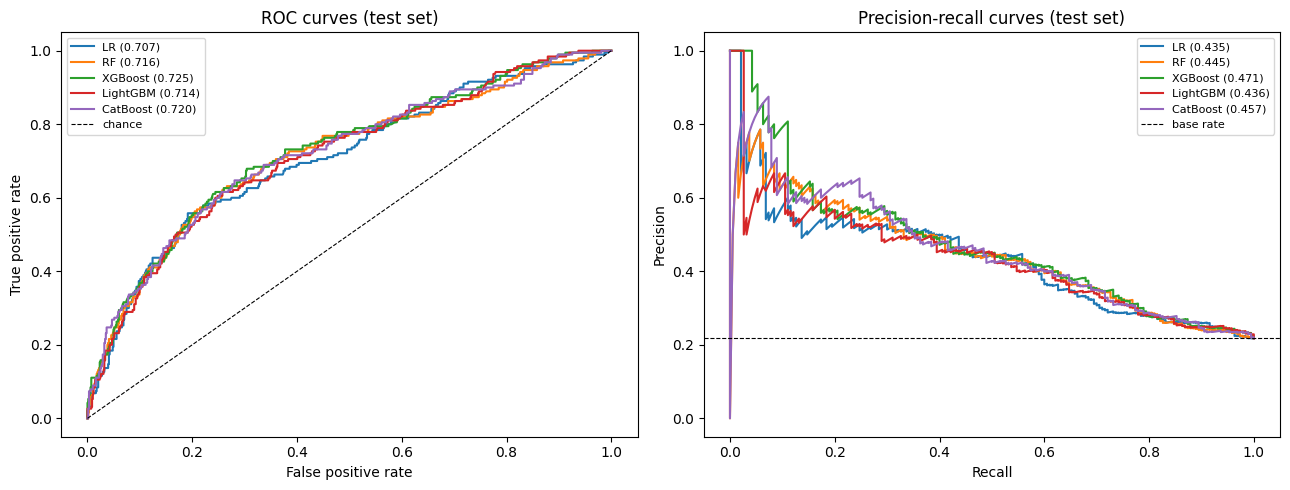

In [5]:
# ROC and precision-recall curves
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in MODEL_ORDER:
    p = P_test[name]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, p):.3f})')
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, label=f'{name} ({average_precision_score(y_test, p):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='chance')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title='ROC curves (test set)')
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', ls='--', lw=0.8, label='base rate')
axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision-recall curves (test set)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG}/f41_roc_pr.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Section 3.11.4 — calibration

Brier scores on the test set, and reliability diagrams. A well-calibrated model
lies on the diagonal: among loans assigned a probability near 0.3, about 30%
should actually default.

In [7]:
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

base_p = np.full(len(y_test), y_tr.mean())
print(f'Baseline (predict base rate {y_tr.mean():.4f}):')
print(f'  Brier    = {brier_score_loss(y_test, base_p):.5f}')
print(f'  log loss = {log_loss(y_test, base_p):.5f}\n')

rows = []
for name in MODEL_ORDER:
    p = P_test[name]
    rows.append({'Model': name,
                 'Brier': round(brier_score_loss(y_test, p), 5),
                 'Log loss': round(log_loss(y_test, p), 5),
                 'Mean p': round(p.mean(), 4)})

calibration = pd.DataFrame(rows).sort_values('Brier')
calibration.to_csv(f'{ART}/t42_calibration.csv', index=False)
print(calibration.to_string(index=False))

Baseline (predict base rate 0.2179):
  Brier    = 0.17013
  log loss = 0.52359

   Model   Brier  Log loss  Mean p
 XGBoost 0.14916   0.46770  0.2158
CatBoost 0.14939   0.46889  0.2157
      RF 0.14975   0.46926  0.2184
LightGBM 0.15070   0.47014  0.2195
      LR 0.15162   0.47343  0.2130


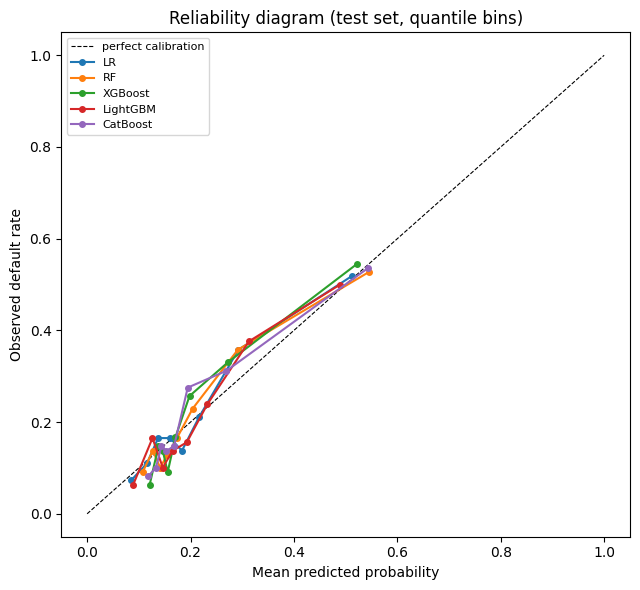

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='perfect calibration')

for name in MODEL_ORDER:
    frac_pos, mean_pred = calibration_curve(y_test, P_test[name],
                                            n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', ms=4, label=name)

ax.set(xlabel='Mean predicted probability', ylabel='Observed default rate',
       title='Reliability diagram (test set, quantile bins)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/f42_reliability.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Sections 3.8.3 and 3.10 — decision thresholds

Three thresholds per model:

1. **0.5** — the conventional default, included as a reference.
2. **p\*** — the cost-derived threshold from Equation 3.2, identical for every
   model since it depends only on the margin and LGD.
3. **Empirical** — the value minimising total cost on the **validation** set,
   searched from 0.01 to 0.99 in steps of 0.01.

All three are fixed before touching the test set.

In [9]:
# Cost inputs (Section 3.8). Costs are example-dependent: each loan carries
# its own principal and its own margin.
LGD = 1.0

L_val  = audit.loc[X_val.index,  'loanamount'].to_numpy()
m_val  = audit.loc[X_val.index,  'interest_margin'].to_numpy()
L_test = audit.loc[X_test.index, 'loanamount'].to_numpy()
m_test = audit.loc[X_test.index, 'interest_margin'].to_numpy()

m_median = audit['interest_margin'].median()
P_STAR = m_median / (m_median + LGD)
print(f'median margin m = {m_median:.4f}')
print(f'p* = m / (m + LGD) = {P_STAR:.4f}  (LGD = {LGD})')


def total_cost(y_true, p, threshold, L, m, lgd=LGD):
    """Equation 3.3 — example-dependent misclassification cost."""
    pred = (p >= threshold).astype(int)
    fn = (pred == 0) & (y_true == 1)      # bad loan approved
    fp = (pred == 1) & (y_true == 0)      # good loan rejected
    return float((lgd * L[fn]).sum() + (m[fp] * L[fp]).sum())


def empirical_threshold(y_true, p, L, m, lgd=LGD):
    grid = np.arange(0.01, 1.00, 0.01)
    costs = [total_cost(y_true, p, t, L, m, lgd) for t in grid]
    return float(grid[int(np.argmin(costs))]), costs, grid

median margin m = 0.2250
p* = m / (m + LGD) = 0.1837  (LGD = 1.0)


LR         empirical threshold = 0.15   (p* = 0.1837)
RF         empirical threshold = 0.17   (p* = 0.1837)
XGBoost    empirical threshold = 0.19   (p* = 0.1837)
LightGBM   empirical threshold = 0.23   (p* = 0.1837)
CatBoost   empirical threshold = 0.15   (p* = 0.1837)


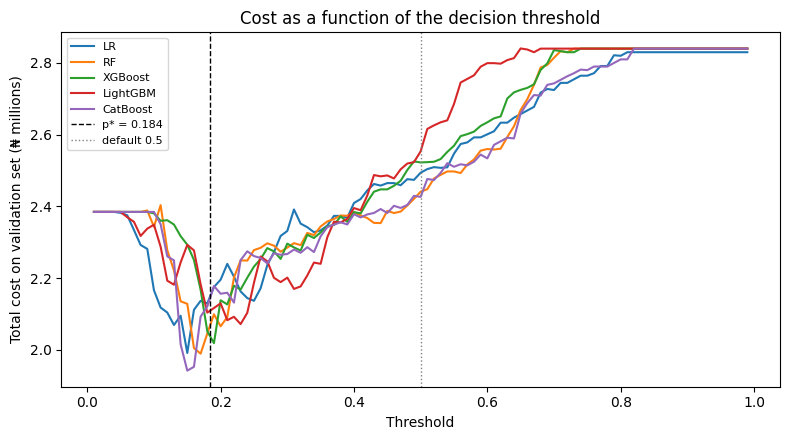

In [10]:
thresholds, curves = {}, {}
for name in MODEL_ORDER:
    t_emp, costs, grid = empirical_threshold(
        y_val.to_numpy(), P_val[name], L_val, m_val)
    thresholds[name] = {'default': 0.50, 'p_star': P_STAR, 'empirical': t_emp}
    curves[name] = (grid, np.array(costs))
    print(f'{name:<10} empirical threshold = {t_emp:.2f}   '
          f'(p* = {P_STAR:.4f})')

fig, ax = plt.subplots(figsize=(8, 4.5))
for name in MODEL_ORDER:
    g, c = curves[name]
    ax.plot(g, c / 1e6, label=name)
ax.axvline(P_STAR, color='k', ls='--', lw=1, label=f'p* = {P_STAR:.3f}')
ax.axvline(0.5, color='grey', ls=':', lw=1, label='default 0.5')
ax.set(xlabel='Threshold', ylabel='Total cost on validation set (₦ millions)',
       title='Cost as a function of the decision threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/f43_threshold_cost.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Section 3.8.5 — cost and classification on the test set

The primary result. For each model and each threshold: the confusion matrix,
recall, precision, F1, and total cost.

In [11]:
from sklearn.metrics import confusion_matrix

rows = []
for name in MODEL_ORDER:
    for label, t in thresholds[name].items():
        p = P_test[name]
        pred = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        cost = total_cost(y_test.to_numpy(), p, t, L_test, m_test)
        rows.append({
            'Model': name, 'Threshold': label, 't': round(t, 4),
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'Rejected': int(pred.sum()),
            'Recall': round(recall, 4), 'Precision': round(precision, 4),
            'F1': round(f1, 4),
            'Total cost': round(cost, 0),
            'Cost/loan': round(cost / len(y_test), 1),
        })

results = pd.DataFrame(rows)
results.to_csv(f'{ART}/t43_cost_results.csv', index=False)
print(results.to_string(index=False))

   Model Threshold      t  TP  FP  TN  FN  Rejected  Recall  Precision     F1  Total cost  Cost/loan
      LR   default 0.5000  26  27 657 164        53  0.1368     0.4906 0.2140   2705750.0     3095.8
      LR    p_star 0.1837 126 253 431  64       379  0.6632     0.3325 0.4429   2062625.0     2360.0
      LR empirical 0.1500 149 386 298  41       535  0.7842     0.2785 0.4110   2146625.0     2456.1
      RF   default 0.5000  41  31 653 149        72  0.2158     0.5694 0.3130   2546500.0     2913.6
      RF    p_star 0.1837 122 209 475  68       331  0.6421     0.3686 0.4683   2045912.0     2340.9
      RF empirical 0.1700 138 264 420  52       402  0.7263     0.3433 0.4662   1941450.0     2221.3
 XGBoost   default 0.5000  34  27 657 156        61  0.1789     0.5574 0.2709   2609000.0     2985.1
 XGBoost    p_star 0.1837 124 201 483  66       325  0.6526     0.3815 0.4816   2011162.0     2301.1
 XGBoost empirical 0.1900 117 178 506  73       295  0.6158     0.3966 0.4825   2035162.0  

In [12]:
# Reference points: approve everything, reject everything
cost_approve_all = total_cost(y_test.to_numpy(), np.zeros(len(y_test)), 0.5,
                              L_test, m_test)
cost_reject_all  = total_cost(y_test.to_numpy(), np.ones(len(y_test)), 0.5,
                              L_test, m_test)

print(f'Approve every loan : {cost_approve_all:>14,.0f}')
print(f'Reject every loan  : {cost_reject_all:>14,.0f}')
print()

pivot = results.pivot(index='Model', columns='Threshold', values='Total cost')
pivot = pivot[['default', 'p_star', 'empirical']].loc[MODEL_ORDER]
pivot['best saving vs approve-all'] = (
    cost_approve_all - pivot.min(axis=1))
print(pivot.round(0).to_string())

# Normalised cost: 1.0 = approving every loan
norm = (pivot[['default', 'p_star', 'empirical']] / cost_approve_all).round(4)
print('\nNormalised cost (1.0 = approve every loan):')
print(norm.to_string())

Approve every loan :      2,890,000
Reject every loan  :      2,331,700

Threshold    default     p_star  empirical  best saving vs approve-all
Model                                                                 
LR         2705750.0  2062625.0  2146625.0                    827375.0
RF         2546500.0  2045912.0  1941450.0                    948550.0
XGBoost    2609000.0  2011162.0  2035162.0                    878838.0
LightGBM   2689500.0  1986312.0  2102562.0                    903688.0
CatBoost   2544000.0  1904350.0  2153450.0                    985650.0

Normalised cost (1.0 = approve every loan):
Threshold  default  p_star  empirical
Model                                
LR          0.9362  0.7137     0.7428
RF          0.8811  0.7079     0.6718
XGBoost     0.9028  0.6959     0.7042
LightGBM    0.9306  0.6873     0.7275
CatBoost    0.8803  0.6589     0.7451


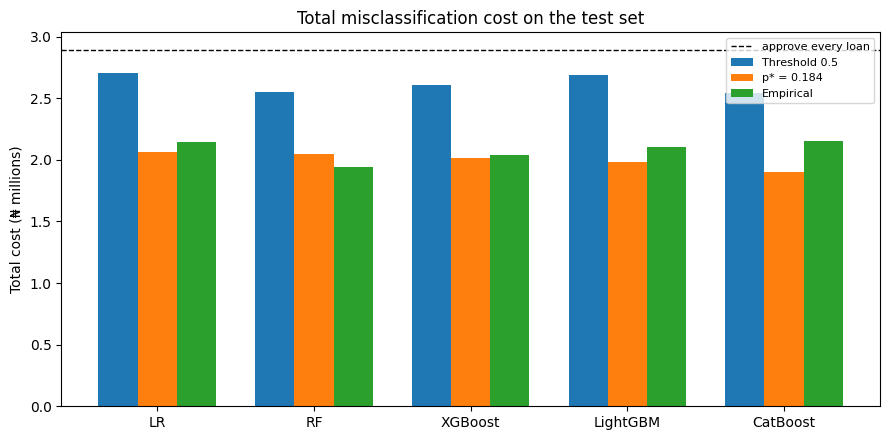

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.25
xs = np.arange(len(MODEL_ORDER))
for i, label in enumerate(['default', 'p_star', 'empirical']):
    vals = [results[(results.Model == mdl) &
                    (results.Threshold == label)]['Total cost'].iloc[0] / 1e6
            for mdl in MODEL_ORDER]
    ax.bar(xs + (i - 1) * w, vals, w,
           label={'default': 'Threshold 0.5',
                  'p_star': f'p* = {P_STAR:.3f}',
                  'empirical': 'Empirical'}[label])

ax.axhline(cost_approve_all / 1e6, color='k', ls='--', lw=1,
           label='approve every loan')
ax.set_xticks(xs); ax.set_xticklabels(MODEL_ORDER)
ax.set(ylabel='Total cost (₦ millions)',
       title='Total misclassification cost on the test set')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/f44_cost_by_model.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Section 3.8.4 — LGD sensitivity

LGD = 1 assumes total loss of principal, an upper bound. The threshold and the
resulting cost are recalculated across a range of recovery assumptions.

In [14]:
rows = []
for lgd in [0.25, 0.50, 0.75, 1.00]:
    p_star_l = m_median / (m_median + lgd)
    for name in MODEL_ORDER:
        cost = total_cost(y_test.to_numpy(), P_test[name], p_star_l,
                          L_test, m_test, lgd=lgd)
        pred = (P_test[name] >= p_star_l).astype(int)
        rows.append({'LGD': lgd, 'p*': round(p_star_l, 4), 'Model': name,
                     'Rejected': int(pred.sum()),
                     'Rejection rate': round(pred.mean(), 3),
                     'Total cost': round(cost, 0)})

sens = pd.DataFrame(rows)
sens.to_csv(f'{ART}/t44_lgd_sensitivity.csv', index=False)
print(sens.pivot(index='Model', columns='LGD', values='Total cost')
        .loc[MODEL_ORDER].round(0).to_string())
print()
print(sens.pivot(index='Model', columns='LGD', values='Rejection rate')
        .loc[MODEL_ORDER].to_string())

LGD           0.25       0.50       0.75       1.00
Model                                              
LR        721250.0  1267375.0  1600812.0  2062625.0
RF        690500.0  1244500.0  1730312.0  2045912.0
XGBoost   703500.0  1261500.0  1741788.0  2011162.0
LightGBM  703500.0  1288250.0  1706062.0  1986312.0
CatBoost  669000.0  1277188.0  1724312.0  1904350.0

LGD        0.25   0.50   0.75   1.00
Model                               
LR        0.069  0.162  0.276  0.434
RF        0.093  0.167  0.243  0.379
XGBoost   0.080  0.153  0.229  0.372
LightGBM  0.074  0.192  0.312  0.469
CatBoost  0.080  0.160  0.211  0.360


## 7. Section 3.11.5 — statistical comparison

**DeLong** tests whether two ROC-AUCs differ significantly on the same sample.
**Friedman** tests whether the models differ in rank across cross-validation
folds; where significant, **Nemenyi** identifies which pairs differ.

In [15]:
# DeLong test (DeLong, DeLong & Clarke-Pearson, 1988)
def _midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def delong_var(y_true, preds):
    """Returns AUCs and their covariance matrix for a list of score vectors."""
    y_true = np.asarray(y_true)
    pos = np.array(preds)[:, y_true == 1]
    neg = np.array(preds)[:, y_true == 0]
    k, m, n = pos.shape[0], pos.shape[1], neg.shape[1]

    tx = np.array([_midrank(pos[r]) for r in range(k)])
    ty = np.array([_midrank(neg[r]) for r in range(k)])
    tz = np.array([_midrank(np.r_[pos[r], neg[r]]) for r in range(k)])

    aucs = (tz[:, :m].sum(axis=1) - m * (m + 1) / 2) / (m * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)


from scipy import stats

preds = [P_test[n] for n in MODEL_ORDER]
aucs, cov = delong_var(y_test.to_numpy(), preds)

rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i + 1, len(MODEL_ORDER)):
        var = cov[i, i] + cov[j, j] - 2 * cov[i, j]
        z = (aucs[i] - aucs[j]) / np.sqrt(var) if var > 0 else 0.0
        pval = 2 * (1 - stats.norm.cdf(abs(z)))
        rows.append({'Model A': MODEL_ORDER[i], 'Model B': MODEL_ORDER[j],
                     'AUC A': round(aucs[i], 4), 'AUC B': round(aucs[j], 4),
                     'Difference': round(aucs[i] - aucs[j], 4),
                     'z': round(z, 3), 'p-value': round(pval, 4),
                     'Significant': 'yes' if pval < 0.05 else 'no'})

delong = pd.DataFrame(rows)
delong.to_csv(f'{ART}/t45_delong.csv', index=False)
print(delong.to_string(index=False))

 Model A  Model B  AUC A  AUC B  Difference      z  p-value Significant
      LR       RF 0.7075 0.7157     -0.0082 -0.587   0.5569          no
      LR  XGBoost 0.7075 0.7254     -0.0180 -1.338   0.1808          no
      LR LightGBM 0.7075 0.7142     -0.0068 -0.447   0.6548          no
      LR CatBoost 0.7075 0.7201     -0.0127 -0.988   0.3230          no
      RF  XGBoost 0.7157 0.7254     -0.0098 -1.368   0.1714          no
      RF LightGBM 0.7157 0.7142      0.0014  0.166   0.8684          no
      RF CatBoost 0.7157 0.7201     -0.0045 -0.566   0.5713          no
 XGBoost LightGBM 0.7254 0.7142      0.0112  1.205   0.2283          no
 XGBoost CatBoost 0.7254 0.7201      0.0053  0.541   0.5887          no
LightGBM CatBoost 0.7142 0.7201     -0.0059 -0.484   0.6283          no


In [16]:
# Friedman test across cross-validation folds on the training set.
# Uses the already-tuned models; no re-tuning.
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_auc = {name: [] for name in MODEL_ORDER}

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr), 1):
    for name in MODEL_ORDER:
        Xa = FRAMES[models[name]['kind']][0]
        est = models[name]['model'].estimator if hasattr(
            models[name]['model'], 'estimator') else models[name]['model']
        try:
            e = clone(est)
        except Exception:
            e = est                      # CatBoost: reuse, refit below
        e.fit(Xa.iloc[tr_idx], y_tr.iloc[tr_idx])
        p = e.predict_proba(Xa.iloc[va_idx])[:, 1]
        fold_auc[name].append(roc_auc_score(y_tr.iloc[va_idx], p))
    print(f'fold {fold} done')

folds_df = pd.DataFrame(fold_auc)
print()
print(folds_df.round(4).to_string())
print('\nmean AUC per model:')
print(folds_df.mean().round(4).to_string())

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done

       LR      RF  XGBoost  LightGBM  CatBoost
0  0.7111  0.8396   0.7842    0.8083    0.8041
1  0.7109  0.8710   0.8091    0.8365    0.8243
2  0.7069  0.8706   0.7956    0.8401    0.8146
3  0.6833  0.8410   0.7842    0.8109    0.7909
4  0.7479  0.8816   0.8266    0.8569    0.8550

mean AUC per model:
LR          0.7120
RF          0.8607
XGBoost     0.8000
LightGBM    0.8305
CatBoost    0.8178


In [18]:
# Friedman test across CV folds — fresh estimators, honest out-of-fold scores.
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

best_params = joblib.load(f'{ART}/studies.joblib')

def make_ohe():
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='constant',
                                                   fill_value='Unknown')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False))]), cat_cols),
    ], remainder='drop')

def fresh(name):
    p = best_params[name]
    if name == 'LR':
        return Pipeline([('pre', make_ohe()),
                         ('clf', LogisticRegression(solver='liblinear',
                                                    max_iter=2000,
                                                    random_state=SEED, **p))]), 'ohe'
    if name == 'RF':
        return Pipeline([('pre', make_ohe()),
                         ('clf', RandomForestClassifier(n_jobs=-1,
                                                        random_state=SEED, **p))]), 'ohe'
    if name == 'XGBoost':
        return Pipeline([('pre', make_ohe()),
                         ('clf', XGBClassifier(eval_metric='logloss',
                                               tree_method='hist', n_jobs=-1,
                                               random_state=SEED, **p))]), 'ohe'
    if name == 'LightGBM':
        return LGBMClassifier(verbose=-1, n_jobs=-1, random_state=SEED, **p), 'lgbm'
    if name == 'CatBoost':
        return CatBoostClassifier(cat_features=cat_cols, verbose=0,
                                  random_seed=SEED, allow_writing_files=False,
                                  thread_count=-1, **p), 'cat'

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_auc = {name: [] for name in MODEL_ORDER}

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr), 1):
    for name in MODEL_ORDER:
        est, kind = fresh(name)                 # a brand-new, unfitted model
        Xa = FRAMES[kind][0]
        est.fit(Xa.iloc[tr_idx], y_tr.iloc[tr_idx])
        p = est.predict_proba(Xa.iloc[va_idx])[:, 1]
        fold_auc[name].append(roc_auc_score(y_tr.iloc[va_idx], p))
    print(f'fold {fold} done')

folds_df = pd.DataFrame(fold_auc)
print()
print(folds_df.round(4).to_string())
print('\nmean AUC per model:')
print(folds_df.mean().round(4).to_string())
print('\nSanity check: these should sit near the test-set AUCs (0.707-0.725).')
print('Values in the high 0.8s would indicate in-sample leakage.')

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done

       LR      RF  XGBoost  LightGBM  CatBoost
0  0.6930  0.6794   0.6813    0.6700    0.6898
1  0.6798  0.7013   0.6963    0.7044    0.7082
2  0.6819  0.7045   0.6940    0.7088    0.6909
3  0.6669  0.6942   0.6978    0.6940    0.6801
4  0.7286  0.7453   0.7471    0.7374    0.7498

mean AUC per model:
LR          0.6900
RF          0.7049
XGBoost     0.7033
LightGBM    0.7029
CatBoost    0.7037

Sanity check: these should sit near the test-set AUCs (0.707-0.725).
Values in the high 0.8s would indicate in-sample leakage.


In [19]:
stat, pval = stats.friedmanchisquare(*[folds_df[c] for c in MODEL_ORDER])
print(f'Friedman chi-square = {stat:.4f}, p = {pval:.4f}')

ranks = folds_df.rank(axis=1, ascending=False)
avg_rank = ranks.mean()
print('\naverage rank (1 = best):')
print(avg_rank.round(3).to_string())

k, N = len(MODEL_ORDER), len(folds_df)
q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728,
           6: 2.850, 7: 2.949, 8: 3.031}[k]
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f'\nNemenyi critical difference (alpha = 0.05) = {CD:.3f}')
print(f'largest rank difference observed          = '
      f'{avg_rank.max() - avg_rank.min():.3f}')

if pval < 0.05:
    for i in range(k):
        for j in range(i + 1, k):
            d = abs(avg_rank.iloc[i] - avg_rank.iloc[j])
            if d > CD:
                print(f'  {MODEL_ORDER[i]} vs {MODEL_ORDER[j]}: {d:.3f} > CD')
else:
    print('\nFriedman test not significant: no post-hoc test is performed.')
    print('The models cannot be distinguished by rank across folds.')

# fold-to-fold vs model-to-model variation
print(f'\nspread across folds (mean over models) : '
      f'{(folds_df.max(axis=1) - folds_df.min(axis=1)).mean():.4f}')
print(f'spread across models (mean AUC range)  : '
      f'{folds_df.mean().max() - folds_df.mean().min():.4f}')

Friedman chi-square = 4.0000, p = 0.4060

average rank (1 = best):
LR          4.2
RF          2.8
XGBoost     2.6
LightGBM    3.0
CatBoost    2.4

Nemenyi critical difference (alpha = 0.05) = 2.728
largest rank difference observed          = 1.800

Friedman test not significant: no post-hoc test is performed.
The models cannot be distinguished by rank across folds.

spread across folds (mean over models) : 0.0261
spread across models (mean AUC range)  : 0.0149


In [20]:
fold_means = folds_df.mean(axis=1)
print(f'fold means           : {fold_means.round(4).tolist()}')
print(f'range across folds   : {fold_means.max() - fold_means.min():.4f}')
print(f'range across models  : {folds_df.mean().max() - folds_df.mean().min():.4f}')

fold means           : [0.6827, 0.698, 0.696, 0.6866, 0.7416]
range across folds   : 0.0590
range across models  : 0.0149


## 8. Section 3.12 — SHAP

Explanations for the best model by cost. TreeExplainer for the tree ensembles,
LinearExplainer for Logistic Regression.

In [23]:
import shap

best_row = results.loc[results['Total cost'].idxmin()]
BEST = best_row['Model']
BEST_T = float(best_row['t'])
print(f'Best model by total cost: {BEST} at threshold {BEST_T:.4f} '
      f'({best_row["Threshold"]})')

# SHAP explains the underlying model; the sigmoid calibration applied on top is
# a monotonic transform of its output, so feature attributions are unaffected.
def unwrap(est, depth=5):
    """Peel CalibratedClassifierCV and FrozenEstimator down to the real model."""
    for _ in range(depth):
        if hasattr(est, 'estimator'):
            est = est.estimator
        else:
            break
    return est

kind = models[BEST]['kind']
Xa, _, Xt = FRAMES[kind]
inner = unwrap(models[BEST]['model'])
print('explaining:', type(inner).__name__)

Best model by total cost: CatBoost at threshold 0.1837 (p_star)
explaining: CatBoostClassifier


In [24]:
# Build the explainer. For pipeline models, SHAP is computed on the
# transformed matrix and feature names come from the ColumnTransformer.
if kind == 'ohe':
    pre = inner.named_steps['pre']
    clf = inner.named_steps['clf']
    Xt_enc = pre.transform(Xt)
    feat_names = pre.get_feature_names_out()
    if BEST == 'LR':
        explainer = shap.LinearExplainer(clf, pre.transform(Xa))
    else:
        explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(Xt_enc)
    X_disp = pd.DataFrame(Xt_enc, columns=feat_names)
else:
    explainer = shap.TreeExplainer(inner)
    sv = explainer.shap_values(Xt)
    X_disp = Xt.copy()
    feat_names = Xt.columns

if isinstance(sv, list):
    sv = sv[1]
if sv.ndim == 3:
    sv = sv[:, :, 1]

print('SHAP values shape:', sv.shape, '| features:', len(feat_names))

SHAP values shape: (874, 19) | features: 19


In [25]:
# Global importance: mean absolute SHAP value
imp = pd.DataFrame({
    'Feature': feat_names,
    'Mean |SHAP|': np.abs(sv).mean(axis=0),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

imp.to_csv(f'{ART}/t46_shap_importance.csv', index=False)
print(imp.head(20).to_string(index=False))

                   Feature  Mean |SHAP|
            prev_late_rate     0.259499
       prev_days_late_mean     0.171793
           interest_margin     0.094258
         bank_account_type     0.093754
 employment_status_clients     0.048487
           prev_amount_max     0.041924
      days_since_last_loan     0.041064
           age_at_approval     0.038772
           prev_loan_count     0.033409
                    region     0.033053
        prev_termdays_mean     0.031889
          prev_amount_mean     0.031724
                  termdays     0.027030
         bank_name_clients     0.021659
level_of_education_clients     0.014840
                loanamount     0.012952
              was_referred     0.003533
          has_demographics     0.002373
               has_history     0.000362


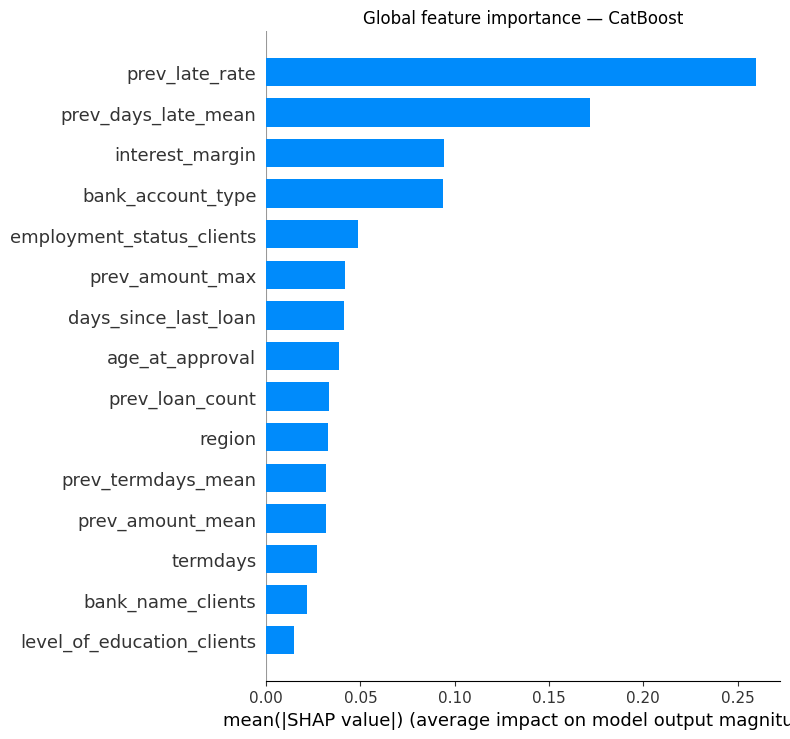

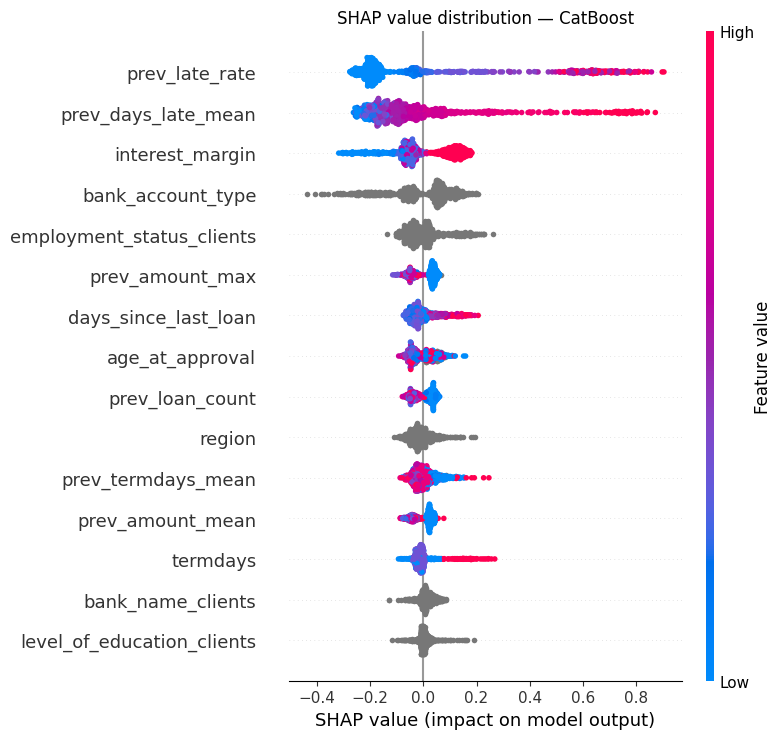

In [26]:
plt.figure()
shap.summary_plot(sv, X_disp, plot_type='bar', max_display=15, show=False)
plt.title(f'Global feature importance — {BEST}')
plt.tight_layout()
plt.savefig(f'{FIG}/f45_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(sv, X_disp, max_display=15, show=False)
plt.title(f'SHAP value distribution — {BEST}')
plt.tight_layout()
plt.savefig(f'{FIG}/f46_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()

In [27]:
# Local explanations: four contrasting test cases (Section 3.12)
p_best = P_test[BEST]
pred_best = (p_best >= BEST_T).astype(int)
yt = y_test.to_numpy()

cases = {}
tp_idx = np.where((pred_best == 1) & (yt == 1))[0]
tn_idx = np.where((pred_best == 0) & (yt == 0))[0]
fn_idx = np.where((pred_best == 0) & (yt == 1))[0]

if len(tp_idx): cases['Correctly identified bad loan'] = tp_idx[np.argmax(p_best[tp_idx])]
if len(tn_idx): cases['Correctly approved good loan'] = tn_idx[np.argmin(p_best[tn_idx])]
if len(fn_idx): cases['Missed bad loan (false negative)'] = fn_idx[np.argmin(p_best[fn_idx])]
cases['Borderline case near p*'] = int(np.argmin(np.abs(p_best - BEST_T)))

for label, i in cases.items():
    print(f'{label:<35} row {i:>4}  p = {p_best[i]:.4f}  actual = {yt[i]}')

Correctly identified bad loan       row  698  p = 0.8000  actual = 1
Correctly approved good loan        row  585  p = 0.0994  actual = 0
Missed bad loan (false negative)    row  438  p = 0.1077  actual = 1
Borderline case near p*             row  386  p = 0.1838  actual = 1


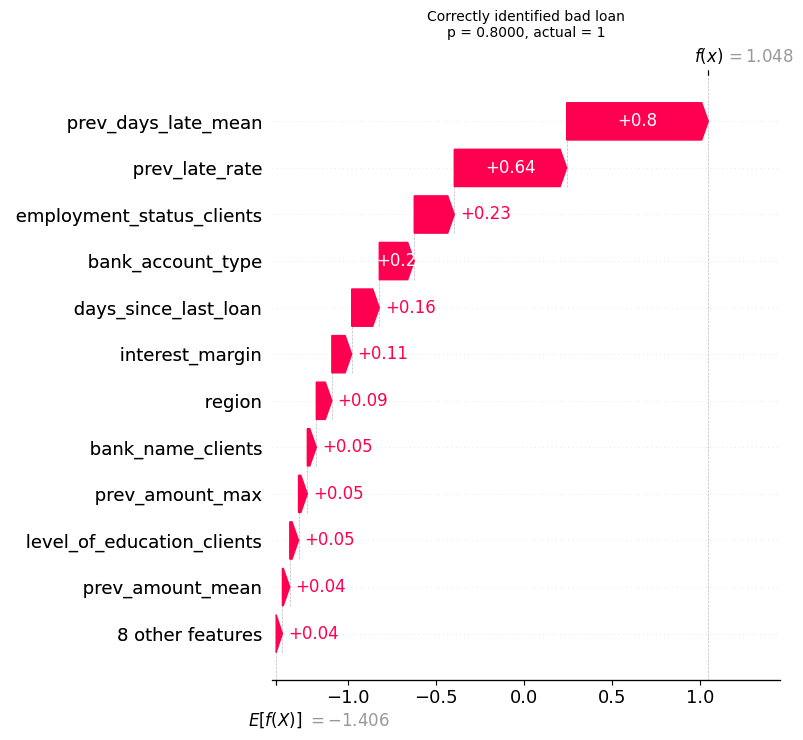

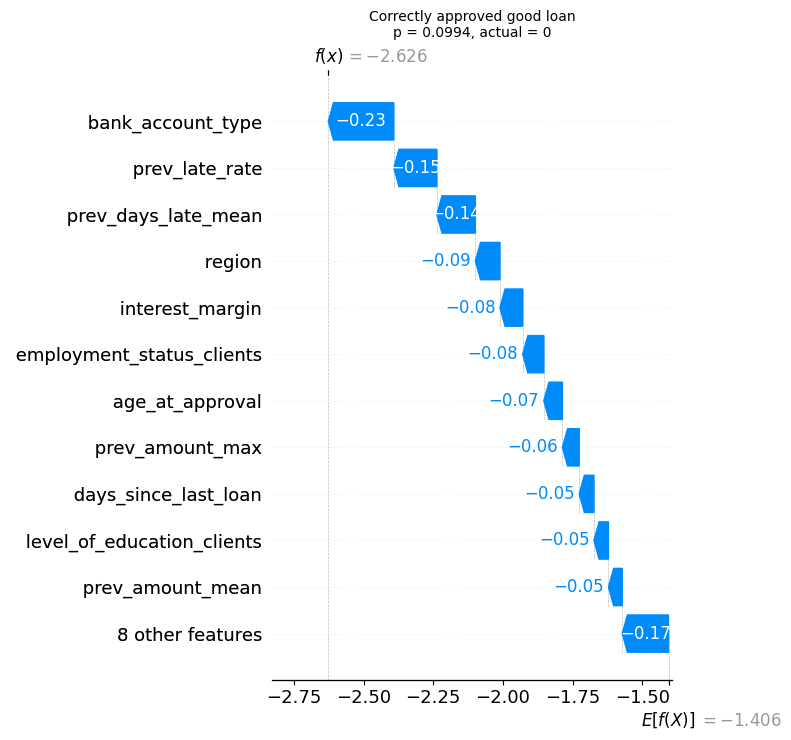

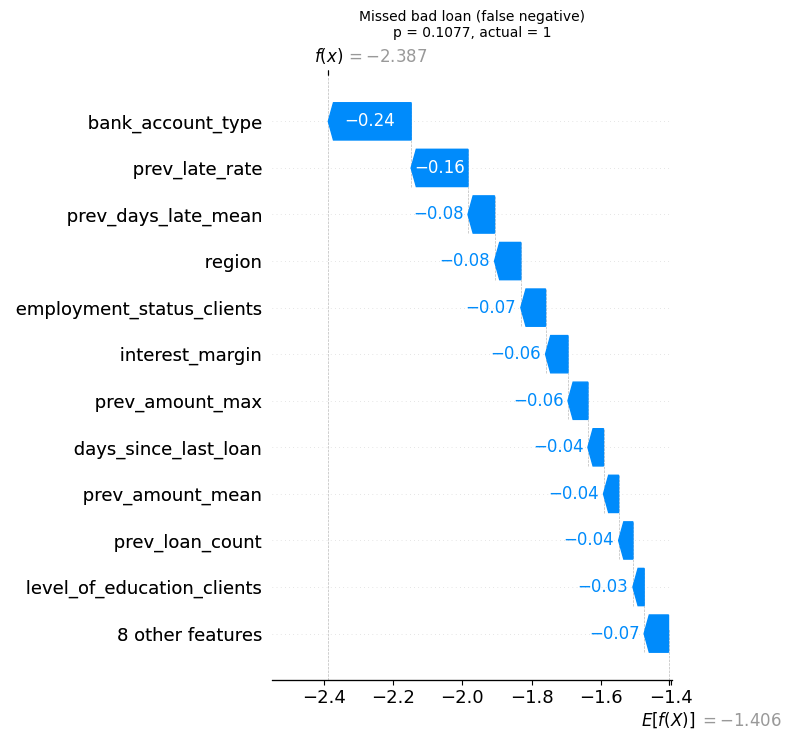

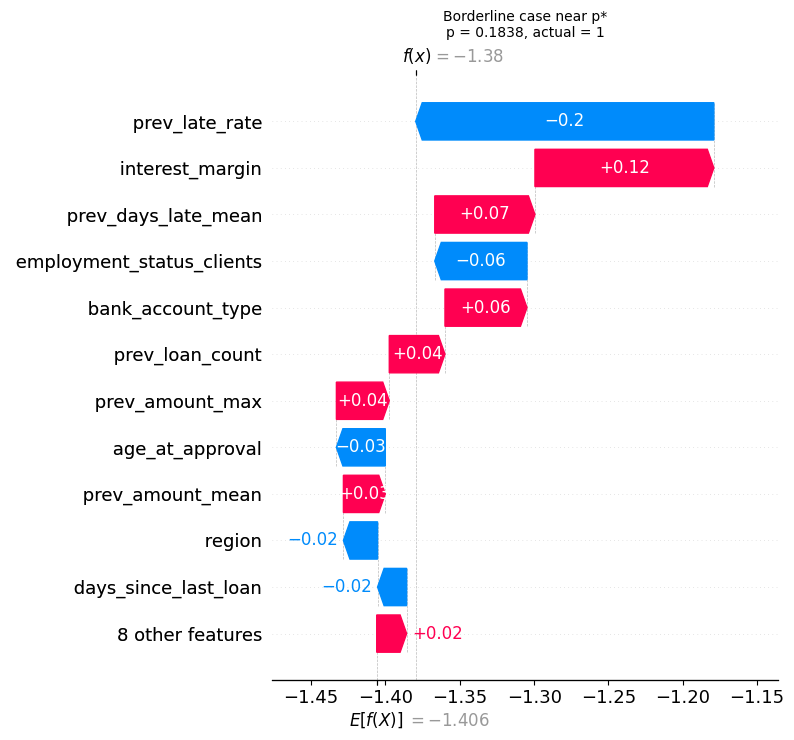

In [29]:
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.atleast_1d(base_value)[-1]

for label, i in cases.items():
    plt.figure()
    shap.plots._waterfall.waterfall_legacy(
        base_value, sv[i], X_disp.iloc[i], max_display=12, show=False)
    plt.title(f'{label}\np = {p_best[i]:.4f}, actual = {yt[i]}', fontsize=10)
    plt.tight_layout()
    fname = ''.join(ch if ch.isalnum() or ch in '-_' else '_'
                    for ch in label.lower().replace(' ', '_'))
    plt.savefig(f'{FIG}/f47_waterfall_{fname}.png', dpi=200, bbox_inches='tight')
    plt.show()

## 9. Section 3.13 — fairness audit

Metrics computed per group on the test set, at the chosen threshold, for the
two protected attributes: `region_fair` (five groups) and `age_band` (four).

Group sizes are reported alongside, and groups below the stated minimum are
flagged rather than silently interpreted.

In [30]:
MIN_GROUP = 30

reg_test = audit.loc[X_test.index, 'region_fair'].to_numpy()
age_test = audit.loc[X_test.index, 'age_band'].to_numpy()

def group_metrics(y_true, pred, p, groups, attr_name):
    rows = []
    for g in pd.unique(groups):
        mask = groups == g
        n = int(mask.sum())
        yt_g, pr_g = y_true[mask], pred[mask]
        tn = int(((pr_g == 0) & (yt_g == 0)).sum())
        fp = int(((pr_g == 1) & (yt_g == 0)).sum())
        fn = int(((pr_g == 0) & (yt_g == 1)).sum())
        tp = int(((pr_g == 1) & (yt_g == 1)).sum())
        rows.append({
            'Attribute': attr_name, 'Group': g, 'n': n,
            'Defaults': int(yt_g.sum()),
            'Rejection rate': round(pr_g.mean(), 4),
            'Approval rate': round(1 - pr_g.mean(), 4),
            'TPR': round(tp / (tp + fn), 4) if (tp + fn) else np.nan,
            'FPR': round(fp / (fp + tn), 4) if (fp + tn) else np.nan,
            'Reliable': 'yes' if n >= MIN_GROUP else 'NO — too small',
        })
    return pd.DataFrame(rows).sort_values('n', ascending=False)


pred_best = (P_test[BEST] >= BEST_T).astype(int)
fair_reg = group_metrics(yt, pred_best, P_test[BEST], reg_test, 'region_fair')
fair_age = group_metrics(yt, pred_best, P_test[BEST], age_test, 'age_band')

fairness = pd.concat([fair_reg, fair_age], ignore_index=True)
fairness.to_csv(f'{ART}/t47_fairness_groups.csv', index=False)
print(f'Model: {BEST} at threshold {BEST_T:.4f}\n')
print(fair_reg.to_string(index=False))
print()
print(fair_age.to_string(index=False))

Model: CatBoost at threshold 0.1837

  Attribute         Group   n  Defaults  Rejection rate  Approval rate    TPR    FPR Reliable
region_fair    South West 434        91          0.3664         0.6336 0.6154 0.3003      yes
region_fair       Unknown 233        54          0.3519         0.6481 0.6667 0.2570      yes
region_fair North Central  92        15          0.3370         0.6630 0.7333 0.2597      yes
region_fair   South South  77        17          0.3377         0.6623 0.7059 0.2333      yes
region_fair Other regions  38        13          0.4474         0.5526 0.6154 0.3600      yes

Attribute   Group   n  Defaults  Rejection rate  Approval rate    TPR    FPR Reliable
 age_band   25-34 387        81          0.3463         0.6537 0.6420 0.2680      yes
 age_band Unknown 228        53          0.3553         0.6447 0.6604 0.2629      yes
 age_band     35+ 218        45          0.3394         0.6606 0.6444 0.2601      yes
 age_band   18-24  41        11          0.6341       

In [31]:
# Summary differences (Section 3.13.3), computed over reliable groups only
def disparities(df_):
    ok = df_[df_['Reliable'] == 'yes']
    if len(ok) < 2:
        return None
    return {
        'Demographic parity difference': round(
            ok['Rejection rate'].max() - ok['Rejection rate'].min(), 4),
        'Disparate impact ratio': round(
            ok['Approval rate'].min() / ok['Approval rate'].max(), 4),
        'Equal opportunity difference': round(
            ok['TPR'].max() - ok['TPR'].min(), 4),
        'Equalised odds difference': round(max(
            ok['TPR'].max() - ok['TPR'].min(),
            ok['FPR'].max() - ok['FPR'].min()), 4),
        'Groups used': len(ok),
        'Groups excluded (too small)': len(df_) - len(ok),
    }

summary_rows = []
for attr, d in [('region_fair', fair_reg), ('age_band', fair_age)]:
    res_ = disparities(d)
    if res_:
        res_['Attribute'] = attr
        summary_rows.append(res_)

disp = pd.DataFrame(summary_rows).set_index('Attribute')
disp.to_csv(f'{ART}/t48_fairness_summary.csv')
print(disp.T.to_string())
print('\nFour-fifths rule: a disparate impact ratio below 0.80 indicates')
print('potential adverse impact (Feldman et al., 2015).')

Attribute                      region_fair  age_band
Demographic parity difference       0.1104    0.2947
Disparate impact ratio              0.8335    0.5539
Equal opportunity difference        0.1179    0.0240
Equalised odds difference           0.1267    0.3732
Groups used                         5.0000    4.0000
Groups excluded (too small)         0.0000    0.0000

Four-fifths rule: a disparate impact ratio below 0.80 indicates
potential adverse impact (Feldman et al., 2015).


In [32]:
# Cross-check with Fairlearn (Bird et al., 2020)
from fairlearn.metrics import (MetricFrame, selection_rate,
                               true_positive_rate, false_positive_rate,
                               demographic_parity_difference,
                               equalized_odds_difference)

for attr, groups in [('region_fair', reg_test), ('age_band', age_test)]:
    mf = MetricFrame(
        metrics={'selection_rate': selection_rate,
                 'TPR': true_positive_rate,
                 'FPR': false_positive_rate},
        y_true=yt, y_pred=pred_best, sensitive_features=groups)
    print(f'--- {attr} ---')
    print(mf.by_group.round(4).to_string())
    print('demographic parity difference:',
          round(demographic_parity_difference(yt, pred_best,
                                              sensitive_features=groups), 4))
    print('equalised odds difference    :',
          round(equalized_odds_difference(yt, pred_best,
                                          sensitive_features=groups), 4))
    print()

--- region_fair ---
                     selection_rate     TPR     FPR
sensitive_feature_0                                
North Central                0.3370  0.7333  0.2597
Other regions                0.4474  0.6154  0.3600
South South                  0.3377  0.7059  0.2333
South West                   0.3664  0.6154  0.3003
Unknown                      0.3519  0.6667  0.2570
demographic parity difference: 0.1104
equalised odds difference    : 0.1267

--- age_band ---
                     selection_rate     TPR     FPR
sensitive_feature_0                                
18-24                        0.6341  0.6364  0.6333
25-34                        0.3463  0.6420  0.2680
35+                          0.3394  0.6444  0.2601
Unknown                      0.3553  0.6604  0.2629
demographic parity difference: 0.2947
equalised odds difference    : 0.3732



## 10. Section 3.13.5 — mitigation

`ThresholdOptimizer` is fitted on the **validation** set and applied unchanged
to the test set, so no mitigation decision is informed by the data used for
final evaluation. The increase in total cost is the price of the fairness
improvement.

As stated in Section 3.13.5, this quantifies the fairness-cost frontier; it is
not put forward as a deployable policy, since applying different thresholds by
age or region is itself differential treatment.

In [33]:
from fairlearn.postprocessing import ThresholdOptimizer

reg_val = audit.loc[X_val.index, 'region_fair'].to_numpy()
age_val = audit.loc[X_val.index, 'age_band'].to_numpy()

_, Xv_best, Xt_best = FRAMES[models[BEST]['kind']]
cost_base = total_cost(yt, P_test[BEST], BEST_T, L_test, m_test)

mitigation_rows = []
for attr, gv, gt in [('region_fair', reg_val, reg_test),
                     ('age_band',    age_val, age_test)]:
    for constraint in ['equalized_odds', 'true_positive_rate_parity']:
        to = ThresholdOptimizer(
            estimator=models[BEST]['model'],
            constraints=constraint,
            objective='accuracy_score',
            prefit=True,
            predict_method='predict_proba')
        to.fit(Xv_best, y_val, sensitive_features=gv)
        pred_mit = to.predict(Xt_best, sensitive_features=gt,
                              random_state=SEED).astype(int)

        # Cost of the mitigated decisions: threshold 0.5 on a 0/1 vector
        cost_mit = total_cost(yt, pred_mit.astype(float), 0.5, L_test, m_test)

        mitigation_rows.append({
            'Attribute': attr, 'Constraint': constraint,
            'Rejected': int(pred_mit.sum()),
            'Cost before': round(cost_base, 0),
            'Cost after': round(cost_mit, 0),
            'Increase': round(cost_mit - cost_base, 0),
            'Increase %': round(100 * (cost_mit - cost_base) / cost_base, 2),
            'DP diff after': round(demographic_parity_difference(
                yt, pred_mit, sensitive_features=gt), 4),
            'EO diff after': round(equalized_odds_difference(
                yt, pred_mit, sensitive_features=gt), 4),
        })

mit = pd.DataFrame(mitigation_rows)
mit.to_csv(f'{ART}/t49_mitigation.csv', index=False)
print(f'Baseline: {BEST} at t = {BEST_T:.4f}, cost = {cost_base:,.0f}\n')
print(mit.to_string(index=False))

Baseline: CatBoost at t = 0.1837, cost = 1,904,350

  Attribute                Constraint  Rejected  Cost before  Cost after  Increase  Increase %  DP diff after  EO diff after
region_fair            equalized_odds        12    1904350.0   2858000.0  953650.0       50.08         0.0263         0.0769
region_fair true_positive_rate_parity        48    1904350.0   2646500.0  742150.0       38.97         0.0737         0.2088
   age_band            equalized_odds        71    1904350.0   2489000.0  584650.0       30.70         0.0686         0.2716
   age_band true_positive_rate_parity        70    1904350.0   2517500.0  613150.0       32.20         0.0468         0.1930


In [34]:
idx = X_test.index
chk = pd.DataFrame({
    'age_band': audit.loc[idx, 'age_band'].values,
    'prev_loan_count': X_test['prev_loan_count'].values,
    'prev_late_rate': X_test['prev_late_rate'].values,
    'has_history': X_test['has_history'].values,
    'p': P_test[BEST],
})
print(chk.groupby('age_band').agg(
    n=('p', 'size'), mean_p=('p', 'mean'),
    prev_loans=('prev_loan_count', 'mean'),
    late_rate=('prev_late_rate', 'mean')).round(3).to_string())

            n  mean_p  prev_loans  late_rate
age_band                                    
18-24      41   0.235       4.390      0.222
25-34     387   0.218       4.137      0.203
35+       218   0.207       4.229      0.173
Unknown   228   0.217       4.013      0.173


In [35]:
for b in ['18-24', '25-34', '35+']:
    s = chk[chk.age_band == b]['p']
    print(f'{b:<8} n={len(s):>3}  25%={s.quantile(.25):.3f}  '
          f'50%={s.median():.3f}  75%={s.quantile(.75):.3f}  '
          f'share above p*={(s >= 0.1837).mean():.3f}')

18-24    n= 41  25%=0.158  50%=0.196  75%=0.238  share above p*=0.634
25-34    n=387  25%=0.136  50%=0.158  75%=0.217  share above p*=0.346
35+      n=218  25%=0.143  50%=0.159  75%=0.203  share above p*=0.339


**Note on the unmitigated comparison.** The "before" figures come from the
single cost-derived threshold; the "after" figures from group-specific
thresholds chosen to satisfy the stated fairness constraint. The difference is
the fairness-cost trade-off reported in Section 3.13.5.

## 11. Summary of results for Chapter 4

In [41]:
import io, contextlib

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    print('=' * 64)
    print('CHAPTER 4 RESULTS')
    print('=' * 64)
    print(f'Test set                : {len(y_test)} loans, '
          f'{int(y_test.sum())} defaults ({y_test.mean():.2%})')
    print(f'Cost-derived threshold  : p* = {P_STAR:.4f} (LGD = {LGD})')
    print(f'Best model by cost      : {BEST} at t = {BEST_T:.4f}')
    print('\n--- Discrimination (test) ---')
    print(discrimination.to_string(index=False))
    print('\n--- Calibration (test) ---')
    print(calibration.to_string(index=False))
    print('\n--- Cost by model and threshold ---')
    print(pivot.round(0).to_string())
    print('\n--- Normalised cost (1.0 = approve every loan) ---')
    print(norm.to_string())
    print('\n--- Full cost / classification results ---')
    print(results.to_string(index=False))
    print('\n--- LGD sensitivity: total cost ---')
    print(sens.pivot(index='Model', columns='LGD', values='Total cost').round(0).to_string())
    print('\n--- LGD sensitivity: rejection rate ---')
    print(sens.pivot(index='Model', columns='LGD', values='Rejection rate').to_string())
    print('\n--- DeLong ---')
    print(delong.to_string(index=False))
    print('\n--- SHAP importance ---')
    print(imp.to_string(index=False))
    print('\n--- Fairness: region ---')
    print(fair_reg.to_string(index=False))
    print('\n--- Fairness: age ---')
    print(fair_age.to_string(index=False))
    print('\n--- Fairness summary ---')
    print(disp.T.to_string())
    print('\n--- Mitigation ---')
    print(mit.to_string(index=False))
    print(f'\nApprove every loan : {cost_approve_all:>14,.0f}')
    print(f'Reject every loan  : {cost_reject_all:>14,.0f}')
    print(f'Best achieved      : {results["Total cost"].min():>14,.0f}')

txt = buf.getvalue()
with open(f'{ART}/chapter4_summary.txt', 'w', encoding='utf-8') as f:
    f.write(txt)

print(f'written to {ART}/chapter4_summary.txt  ({len(txt)} characters)')
print(txt[:1500])

written to artifacts/chapter4_summary.txt  (7813 characters)
CHAPTER 4 RESULTS
Test set                : 874 loans, 190 defaults (21.74%)
Cost-derived threshold  : p* = 0.1837 (LGD = 1.0)
Best model by cost      : CatBoost at t = 0.1837

--- Discrimination (test) ---
   Model  ROC-AUC  PR-AUC     KS
 XGBoost   0.7254  0.4709 0.3749
CatBoost   0.7201  0.4571 0.3667
      RF   0.7157  0.4450 0.3661
LightGBM   0.7142  0.4358 0.3585
      LR   0.7075  0.4345 0.3664

--- Calibration (test) ---
   Model   Brier  Log loss  Mean p
 XGBoost 0.14916   0.46770  0.2158
CatBoost 0.14939   0.46889  0.2157
      RF 0.14975   0.46926  0.2184
LightGBM 0.15070   0.47014  0.2195
      LR 0.15162   0.47343  0.2130

--- Cost by model and threshold ---
Threshold    default     p_star  empirical  best saving vs approve-all
Model                                                                 
LR         2705750.0  2062625.0  2146625.0                    827375.0
RF         2546500.0  2045912.0  1941450.0    